In [1]:
# 01. IMPORT LIBRARIES

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# 02. PROJECT PATHS

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TCIR_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "satellite"
    / "tcir"
)

IMAGE_FILE = TCIR_DIR / "Cyclone_Images.h5"
LABEL_FILE = TCIR_DIR / "Cyclone_Labels h5.npy"

print("Project root:", PROJECT_ROOT)
print("Image file:", IMAGE_FILE)
print("Label file:", LABEL_FILE)

Project root: e:\SIH\tropical-cyclone-ai
Image file: e:\SIH\tropical-cyclone-ai\data\raw\satellite\tcir\Cyclone_Images.h5
Label file: e:\SIH\tropical-cyclone-ai\data\raw\satellite\tcir\Cyclone_Labels h5.npy


In [3]:
# 03. LOAD TCIR LABELS

labels = np.load(
    LABEL_FILE,
    allow_pickle=True
)

print("Label shape:", labels.shape)
print("Label dtype:", labels.dtype)

Label shape: (21076, 8)
Label dtype: object


In [4]:
# 04. CREATE METADATA TABLE

label_df = pd.DataFrame(
    labels,
    columns=[
        "REGION",
        "CYCLONE_ID",
        "LON",
        "LAT",
        "TIME",
        "WIND_KTS",
        "SIZE",
        "PRESSURE_MB"
    ]
)

label_df["LON"] = pd.to_numeric(label_df["LON"], errors="coerce")
label_df["LAT"] = pd.to_numeric(label_df["LAT"], errors="coerce")
label_df["WIND_KTS"] = pd.to_numeric(label_df["WIND_KTS"], errors="coerce")
label_df["SIZE"] = pd.to_numeric(label_df["SIZE"], errors="coerce")
label_df["PRESSURE_MB"] = pd.to_numeric(
    label_df["PRESSURE_MB"],
    errors="coerce"
)

label_df["TIME"] = pd.to_datetime(
    label_df["TIME"].astype(str),
    format="%Y%m%d%H",
    errors="coerce"
)

display(label_df.head())

,REGION,CYCLONE_ID,LON,LAT,TIME,WIND_KTS,SIZE,PRESSURE_MB
0,ATLN,200301L,-66.0,31.4,2003-04-18 15:00:00,30.0,0.0,1008.0
1,ATLN,200301L,-66.3,31.9,2003-04-18 18:00:00,30.0,0.0,1007.0
2,ATLN,200301L,-66.6,32.5,2003-04-18 21:00:00,30.0,0.0,1007.0
3,ATLN,200301L,-68.6,34.5,2003-04-19 12:00:00,35.0,0.0,1006.0
4,ATLN,200301L,-68.8,34.4,2003-04-19 15:00:00,35.0,0.0,1006.0


In [5]:
# 05. INSPECT IMAGE DATASET

with h5py.File(IMAGE_FILE, "r") as h5:
    print("H5 datasets:", list(h5.keys()))
    
    images = h5["Images"]
    
    print("Image shape:", images.shape)
    print("Image dtype:", images.dtype)
    print("Number of images:", images.shape[0])
    print("Image height:", images.shape[1])
    print("Image width:", images.shape[2])
    print("Number of channels:", images.shape[3])

H5 datasets: ['Images']
Image shape: (21076, 128, 128, 4)
Image dtype: float32
Number of images: 21076
Image height: 128
Image width: 128
Number of channels: 4


In [6]:
# 06. LOAD SAMPLE IMAGE

with h5py.File(IMAGE_FILE, "r") as h5:
    images = h5["Images"]
    sample_image = images[0]

print("Image shape:", sample_image.shape)
print("Image dtype:", sample_image.dtype)
print("Minimum value:", sample_image.min())
print("Maximum value:", sample_image.max())

Image shape: (128, 128, 4)
Image dtype: float32
Minimum value: 0.0
Maximum value: 255.0


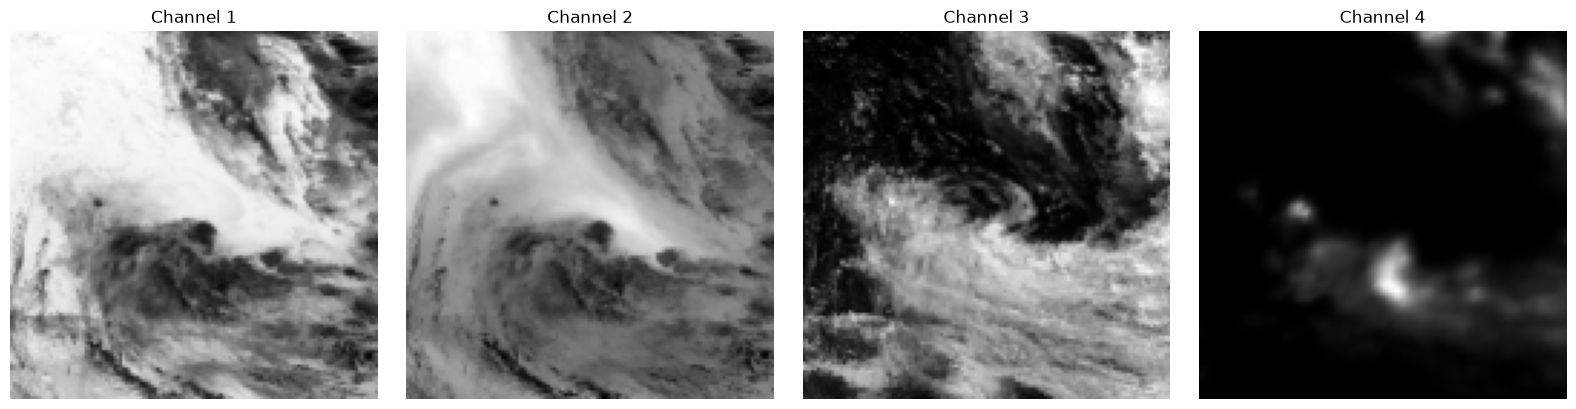

In [29]:
# 07. VISUALIZE IMAGE CHANNELS

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for channel in range(4):
    axes[channel].imshow(
        sample_image[:, :, channel],
        cmap="gray"
        # cmap="coolwarm"
    )
    axes[channel].set_title(f"Channel {channel + 1}")
    axes[channel].axis("off")

plt.tight_layout()
plt.show()

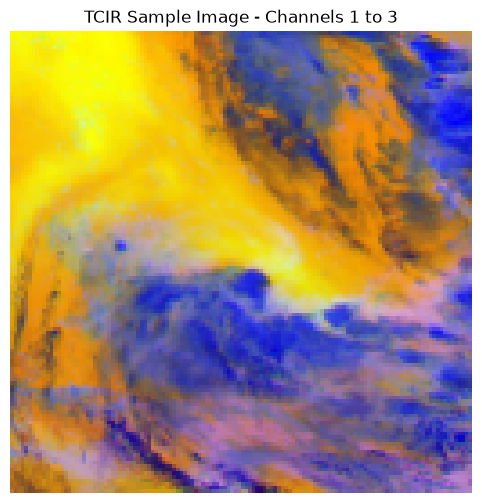

In [30]:
# 08. VISUALIZE RGB COMPOSITE

rgb_image = sample_image[:, :, :3]

plt.figure(figsize=(6, 6))
plt.imshow(
    np.clip(rgb_image / 255.0, 0, 1)
)
plt.title("TCIR Sample Image - Channels 1 to 3")
plt.axis("off")
plt.show()

Cyclone ID: 200301L
Region: ATLN
Time: 2003-04-18 15:00:00
Latitude: 31.4
Longitude: -66.0
Wind (knots): 30.0
Pressure (mb): 1008.0


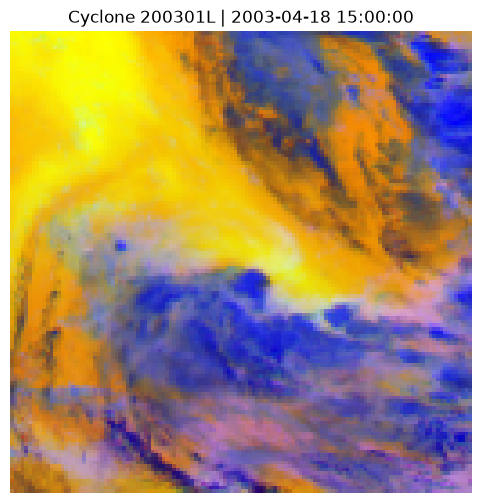

In [31]:
# 09. DISPLAY IMAGE WITH METADATA

sample_metadata = label_df.iloc[0]

print("Cyclone ID:", sample_metadata["CYCLONE_ID"])
print("Region:", sample_metadata["REGION"])
print("Time:", sample_metadata["TIME"])
print("Latitude:", sample_metadata["LAT"])
print("Longitude:", sample_metadata["LON"])
print("Wind (knots):", sample_metadata["WIND_KTS"])
print("Pressure (mb):", sample_metadata["PRESSURE_MB"])

plt.figure(figsize=(6, 6))
plt.imshow(
    np.clip(sample_image[:, :, :3] / 255.0, 0, 1)
)
plt.title(
    f"Cyclone {sample_metadata['CYCLONE_ID']} | "
    f"{sample_metadata['TIME']}"
)
plt.axis("off")
plt.show()

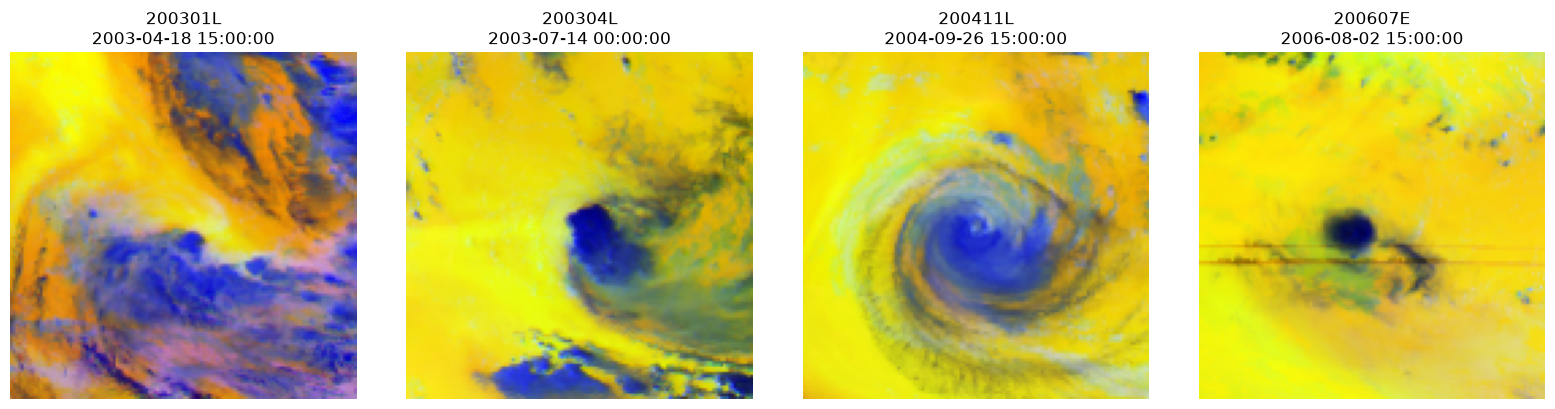

In [32]:
# 10. VISUALIZE MULTIPLE SAMPLE IMAGES

sample_indices = [0, 100, 1000, 5000]

with h5py.File(IMAGE_FILE, "r") as h5:
    images = h5["Images"]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for ax, idx in zip(axes, sample_indices):
        image = images[idx]

        ax.imshow(image[:, :, :3] / 255.0)
        ax.set_title(
            f"{label_df.iloc[idx]['CYCLONE_ID']}\n"
            f"{label_df.iloc[idx]['TIME']}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [33]:
# 11. CHANNEL STATISTICS

with h5py.File(IMAGE_FILE, "r") as h5:
    images = h5["Images"]

    for channel in range(4):
        channel_data = images[:, :, :, channel]

        print(f"Channel {channel + 1}:")
        print(f"  Min:  {channel_data.min():.2f}")
        print(f"  Max:  {channel_data.max():.2f}")
        print(f"  Mean: {channel_data.mean():.2f}")
        print(f"  NaNs: {np.isnan(channel_data[:]).sum()}")
        print()

Channel 1:
  Min:  0.00
  Max:  255.00
  Mean: 180.00
  NaNs: 0

Channel 2:
  Min:  0.00
  Max:  255.00
  Mean: 174.54
  NaNs: 0

Channel 3:
  Min:  0.00
  Max:  255.00
  Mean: 65.76
  NaNs: 0

Channel 4:
  Min:  nan
  Max:  nan
  Mean: nan
  NaNs: 196608



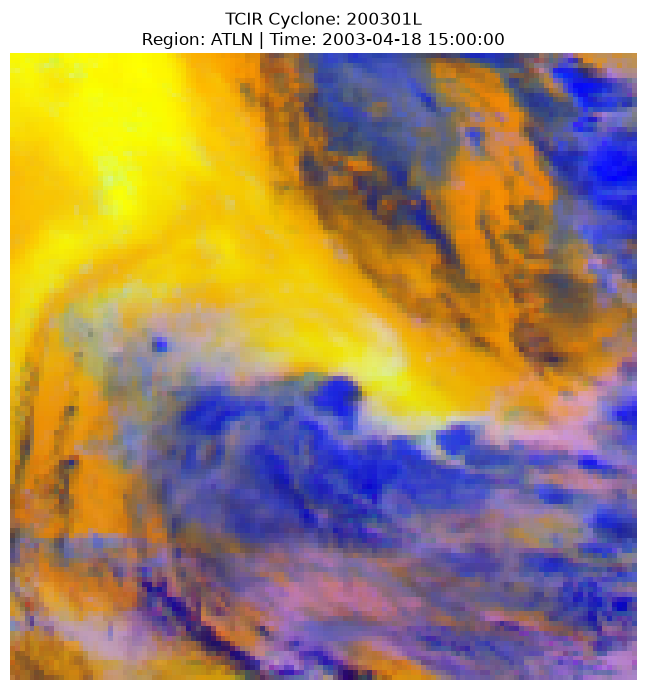

Cyclone ID: 200301L
Region: ATLN
Time: 2003-04-18 15:00:00
Latitude: 31.4
Longitude: -66.0
Wind: 30.0 knots
Pressure: 1008.0 mb


In [34]:
# 12. IMAGE WITH METADATA

idx = 0

with h5py.File(IMAGE_FILE, "r") as h5:
    image = h5["Images"][idx]

metadata = label_df.iloc[idx]

plt.figure(figsize=(7, 7))
plt.imshow(image[:, :, :3] / 255.0)

plt.title(
    f"TCIR Cyclone: {metadata['CYCLONE_ID']}\n"
    f"Region: {metadata['REGION']} | "
    f"Time: {metadata['TIME']}"
)

plt.axis("off")
plt.tight_layout()
plt.show()

print("Cyclone ID:", metadata["CYCLONE_ID"])
print("Region:", metadata["REGION"])
print("Time:", metadata["TIME"])
print("Latitude:", metadata["LAT"])
print("Longitude:", metadata["LON"])
print("Wind:", metadata["WIND_KTS"], "knots")
print("Pressure:", metadata["PRESSURE_MB"], "mb")

In [35]:
# 13. VERIFY IMAGE-LABEL ALIGNMENT

with h5py.File(IMAGE_FILE, "r") as h5:
    image_count = h5["Images"].shape[0]

label_count = len(label_df)

print("Image count:", image_count)
print("Label count:", label_count)
print("Counts match:", image_count == label_count)

Image count: 21076
Label count: 21076
Counts match: True


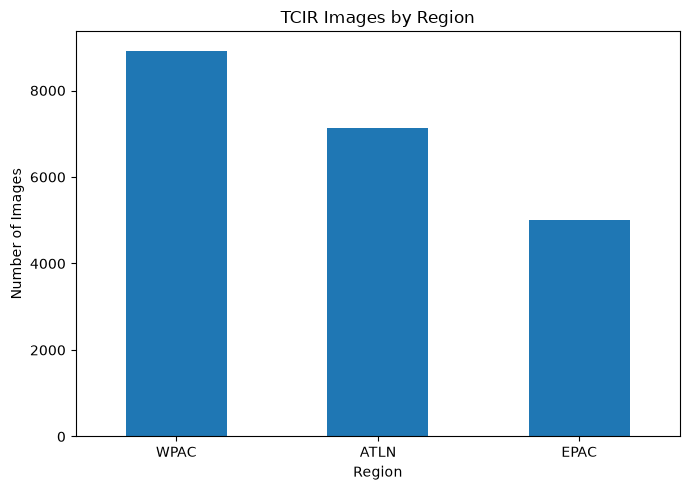

In [36]:
# 14. VISUALIZE REGION DISTRIBUTION

region_counts = label_df["REGION"].value_counts()

plt.figure(figsize=(7, 5))
region_counts.plot(kind="bar")

plt.title("TCIR Images by Region")
plt.xlabel("Region")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

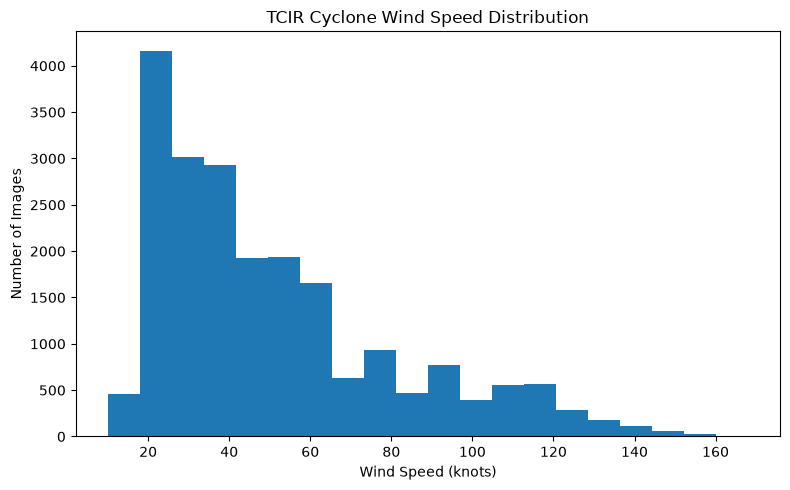

In [37]:
# 15. VISUALIZE WIND DISTRIBUTION

plt.figure(figsize=(8, 5))

plt.hist(
    label_df["WIND_KTS"],
    bins=20
)

plt.title("TCIR Cyclone Wind Speed Distribution")
plt.xlabel("Wind Speed (knots)")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [38]:
# 16. FINAL VISUALIZATION CHECK

with h5py.File(IMAGE_FILE, "r") as h5:
    image_count = h5["Images"].shape[0]

print("Image dataset:")
print("  Images:", image_count)
print("  Shape:", h5["Images"].shape if False else "(128, 128, 4)")

print("\nMetadata:")
print("  Records:", len(label_df))
print("  Unique cyclones:", label_df["CYCLONE_ID"].nunique())

print("\nAlignment:")
print("  Images = Metadata:", image_count == len(label_df))

Image dataset:
  Images: 21076
  Shape: (128, 128, 4)

Metadata:
  Records: 21076
  Unique cyclones: 485

Alignment:
  Images = Metadata: True


## 17. SATELLITE VISUALIZATION SUMMARY

### Dataset

- TCIR satellite image dataset was inspected and visualized.
- Total images: **21,076**
- Image dimensions: **128 × 128 pixels**
- Number of channels: **4**
- Image data type: **float32**
- Pixel values: **0–255**
- Image NaN values: **0**

### Visualization Performed

- Individual visualization of all four image channels.
- Three-channel composite visualization.
- Multiple cyclone image samples.
- Satellite image displayed together with cyclone metadata.
- Region distribution visualization.
- Wind-speed distribution visualization.

### Important Note

The four channels were visualized individually without assigning physical channel names because the channel definitions were not assumed without verification from the dataset documentation.

The visualization confirms that the TCIR dataset contains multi-channel satellite imagery with corresponding cyclone metadata and that the image and metadata counts are aligned.